# Understanding Home Equity Loan Default: A Statistical Learning Exploration

**Dataset:** HMEQ — Home Equity Loan Performance (5,960 loans)
**Author:** *[Your Name]*, Statistical Data Science, Indian Statistical Institute

---

This notebook documents an exploration of the HMEQ home-equity loan dataset, undertaken
while studying *An Introduction to Statistical Learning with Python* (ISLP). The aim was
to examine how the assumptions ISLP introduces in the abstract — linearity, independence,
data missing at random, uncorrelated predictors — behave on a realistic, imperfect
dataset, rather than to maximize a single leaderboard metric.

**Predictive performance is treated as a secondary outcome.** The primary objective is to
motivate and answer a *why* at each stage: why a given imputation strategy, why a given
feature, why a given model, why a given decision threshold. Where a choice that improves
ROC-AUC would come at the cost of interpretability or a defensible statistical
justification, the more defensible option is preferred. Experiments whose results
contradicted the initial hypothesis are reported alongside those that confirmed it, since
both are informative about the underlying data-generating process.

## 1. Problem Statement and Motivation

A home equity loan is borrowed against the equity already accumulated in a property. A
lender must decide, at application time, whether a given applicant is likely to default —
before any repayment history exists for that applicant. Approving too liberally increases
realized losses; declining too conservatively cedes volume to competitors.

This is the applied framing. The narrower motivation for this project, however, is
methodological: introductory treatments of statistical learning routinely invoke
assumptions — linearity, independence, homoscedasticity, data missing at random,
uncorrelated predictors — that are rarely tested explicitly against real data. HMEQ was
selected as a testbed precisely because those assumptions cannot be taken for granted here:
genuine missing data (up to 21% in one column), a clear multicollinearity case, a
meaningfully imbalanced target, and a sample size (5,960 rows) large enough for stable
cross-validated estimates without being so large that confound control becomes trivial.

**Working question.** Given application-time information (loan amount, existing mortgage
balance, property value, employment tenure, credit-bureau attributes), can `BAD`
(1 = defaulted / seriously delinquent) be predicted — and, more importantly, can the
drivers of that prediction be stated in statistically defensible terms?

In [1]:
import sys, os, warnings
warnings.filterwarnings("ignore")
sys.path.insert(0, os.path.abspath("../src"))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from preprocessing import (
    load_raw_data, missingness_report, clean_pipeline, make_train_test_split,
    NUMERIC_COLS, CATEGORICAL_COLS, TARGET_COL,
)
from feature_engineering import add_engineered_features, build_preprocessing_pipeline, get_feature_names
from models import get_model_zoo, get_hyperparameter_grids, RANDOM_STATE
from evaluation import compute_metrics, metrics_table

plt.rcParams.update({"figure.dpi": 100, "axes.grid": True, "grid.alpha": 0.3})
pd.set_option("display.max_columns", 30)

EXP_DIR = "../outputs/experiments"
RAW_PATH = "../data/raw/hmeq.csv"
raw = load_raw_data(RAW_PATH)
print(f"Shape: {raw.shape}")
raw.head()

Shape: (5960, 13)


,BAD,LOAN,MORTDUE,VALUE,REASON,JOB,YOJ,DEROG,DELINQ,CLAGE,NINQ,CLNO,DEBTINC
0,1,1100,25860.0,39025.0,HomeImp,Other,10.5,0.0,0.0,94.366667,1.0,9.0,NaN
1,1,1300,70053.0,68400.0,HomeImp,Other,7.0,0.0,2.0,121.833333,0.0,14.0,NaN
2,1,1500,13500.0,16700.0,HomeImp,Other,4.0,0.0,0.0,149.466667,1.0,10.0,NaN
3,1,1500,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,0,1700,97800.0,112000.0,HomeImp,Office,3.0,0.0,0.0,93.333333,0.0,14.0,NaN


| Column | Meaning |
|---|---|
| `BAD` | Target: 1 = defaulted / seriously delinquent, 0 = repaid |
| `LOAN` | Requested loan amount (USD) |
| `MORTDUE` | Amount due on existing mortgage |
| `VALUE` | Current value of the property |
| `REASON` | `DebtCon` (debt consolidation) or `HomeImp` (home improvement) |
| `JOB` | Occupation category |
| `YOJ` | Years at present job |
| `DEROG` | Number of major derogatory credit reports |
| `DELINQ` | Number of delinquent credit lines |
| `CLAGE` | Age of oldest credit line, in months |
| `NINQ` | Number of recent credit inquiries |
| `CLNO` | Number of existing credit lines |
| `DEBTINC` | Debt-to-income ratio (%) |


In [2]:
raw.info()
print()
print("Target balance:")
print(raw[TARGET_COL].value_counts(normalize=True).round(3))

<class 'pandas.DataFrame'>
RangeIndex: 5960 entries, 0 to 5959
Data columns (total 13 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   BAD      5960 non-null   int64  
 1   LOAN     5960 non-null   int64  
 2   MORTDUE  5442 non-null   float64
 3   VALUE    5848 non-null   float64
 4   REASON   5708 non-null   str    
 5   JOB      5681 non-null   str    
 6   YOJ      5445 non-null   float64
 7   DEROG    5252 non-null   float64
 8   DELINQ   5380 non-null   float64
 9   CLAGE    5652 non-null   float64
 10  NINQ     5450 non-null   float64
 11  CLNO     5738 non-null   float64
 12  DEBTINC  4693 non-null   float64
dtypes: float64(9), int64(2), str(2)
memory usage: 605.4 KB

Target balance:
BAD
0    0.801
1    0.199
Name: proportion, dtype: float64


**Initial characterization.** The dataset comprises 5,960 rows, 13 columns, and an
approximately 80/20 class split. This imbalance has an immediate methodological
consequence: accuracy is a near-uninformative metric here, since a classifier that always
predicts "repaid" already scores 80%. ROC-AUC and PR-AUC are therefore used as the primary
evaluation metrics throughout, rather than introduced only at the end.

## 2. Exploratory Data Analysis

Before any modelling, the data are examined directly. Two questions motivate this section:
how skewed are the monetary variables (relevant to the choice between mean and median
imputation, and to whether log-transforms are warranted), and how correlated are the
predictors with one another (relevant to whether multicollinearity should be treated as a
concern).

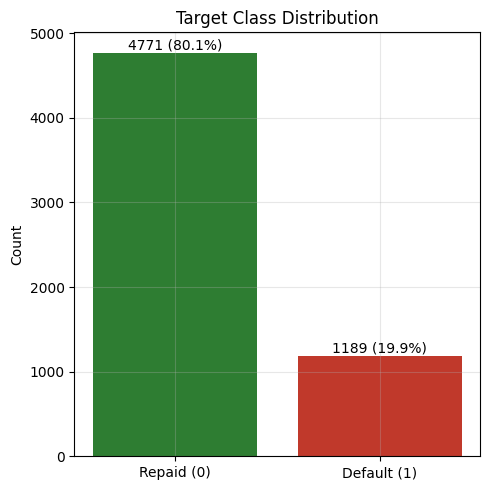

In [3]:
fig, ax = plt.subplots(figsize=(5,5))
counts = raw[TARGET_COL].value_counts().sort_index()
ax.bar(["Repaid (0)", "Default (1)"], counts.values, color=["#2e7d32", "#c0392b"])
for i, v in enumerate(counts.values):
    ax.text(i, v+40, f"{v} ({v/len(raw)*100:.1f}%)", ha="center")
ax.set_title("Target Class Distribution"); ax.set_ylabel("Count")
plt.tight_layout(); plt.show()

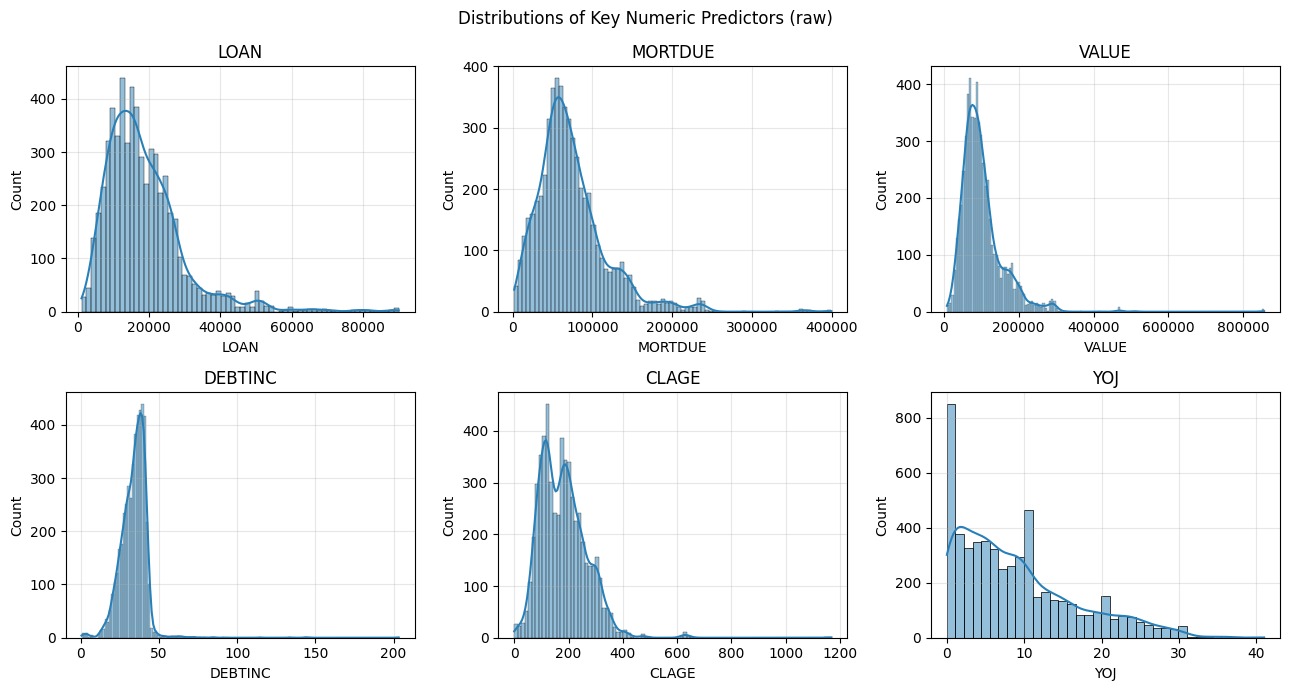

In [4]:
fig, axes = plt.subplots(2, 3, figsize=(13,7))
for ax, col in zip(axes.ravel(), ["LOAN","MORTDUE","VALUE","DEBTINC","CLAGE","YOJ"]):
    sns.histplot(raw[col].dropna(), kde=True, ax=ax, color="#2980b9")
    ax.set_title(col)
fig.suptitle("Distributions of Key Numeric Predictors (raw)")
plt.tight_layout(); plt.show()

**Observation.** `LOAN`, `MORTDUE`, and `VALUE` are visibly right-skewed: a small number
of large loans and high-value properties pull the mean well above the typical applicant.
This motivates the imputation question addressed in Section 3 — mean imputation under this
skew risks inserting an atypical "average" applicant, whereas the median is more robust to
the skew by construction. This observation is treated as a hypothesis to be tested in
Section 3, not as a decision made in advance.

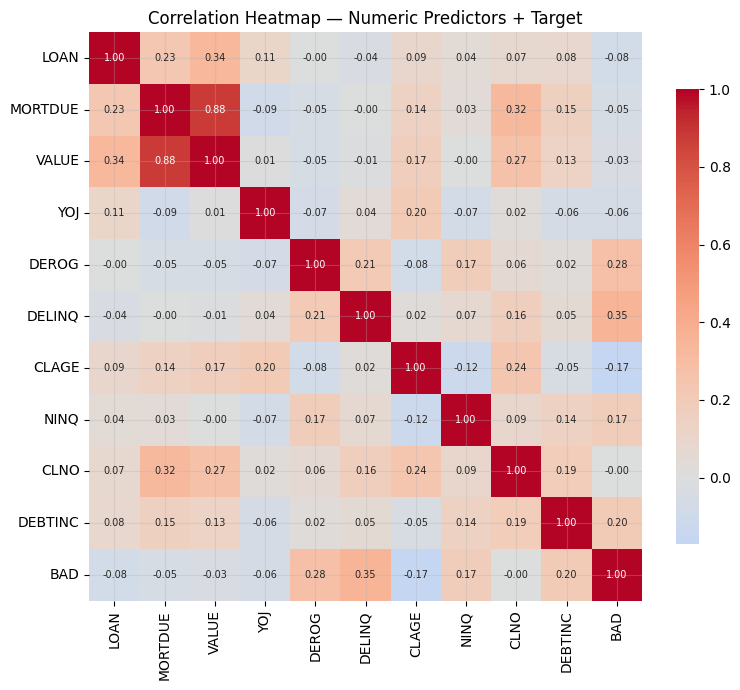

In [5]:
corr = raw[NUMERIC_COLS + [TARGET_COL]].corr()
fig, ax = plt.subplots(figsize=(8,7))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0, ax=ax,
            cbar_kws={"shrink":0.8}, annot_kws={"size":7})
ax.set_title("Correlation Heatmap — Numeric Predictors + Target")
plt.tight_layout(); plt.show()

**Correlation structure.** `MORTDUE` and `VALUE` correlate at $\rho = 0.88$. This is not
incidental — a larger property tends to carry a larger mortgage — but it is exactly the
condition under which an unpenalized linear model's coefficient variance is expected to
inflate (ISLP §3.3.3). Rather than dropping one of the two variables on the strength of
this correlation alone, the question is deferred to a controlled experiment in Section 8.

The next-strongest marginal associations with the target are `DELINQ` ($\rho = 0.35$) and
`DEROG` ($\rho = 0.28$), both positive and consistent with underwriting intuition, and
`CLAGE` ($\rho = -0.17$), indicating that a longer credit history is protective. These are
marginal *linear* associations only; Section 14 shows that the full non-linear picture,
recovered by the tree ensembles, is not fully captured by pairwise correlation.

## 3. Missing Data Analysis and Imputation Strategy

**Question.** How should missing values be handled, and does explicitly encoding *which*
values are missing — rather than imputing and discarding that information — improve
predictive performance, or does it add columns without benefit?

**Hypothesis.** Fields such as `DEBTINC` are self-reported or bureau-derived, and
applicants who cannot report a clean debt-to-income figure (for example, those with
self-employment or non-traditional income) plausibly constitute a distinct subpopulation
rather than a random subset of applicants. This is consistent with data that are **missing
not at random (MNAR)** rather than missing completely at random. Under this hypothesis, the
fact of missingness itself carries information that imputation alone would discard.

**Experimental design.** The model is held fixed (L2-penalized logistic regression, same
cross-validation folds throughout) while only the missing-value treatment is varied, so
that any resulting performance difference is attributable to the treatment rather than to
the choice of model (full code: `src/exp_missing_value_strategy.py`).

In [6]:
mv = pd.read_csv(f"{EXP_DIR}/exp_missing_value_strategy.csv")
mv = mv.sort_values("roc_auc", ascending=False).reset_index(drop=True)
mv

,experiment,variant,n_rows,n_features,roc_auc,roc_auc_std,pr_auc,f1
0,missing_value_strategy,mean_impute_with_flags,5960,21,0.9035,0.0106,0.7846,0.6876
1,missing_value_strategy,median_impute_with_flags,5960,21,0.9035,0.0106,0.7846,0.6873
2,missing_value_strategy,knn_impute_with_flags,5960,21,0.9022,0.0108,0.7758,0.6783
3,missing_value_strategy,median_impute_no_flags,5960,12,0.8011,0.0115,0.5901,0.4410
4,missing_value_strategy,mean_impute_no_flags,5960,12,0.7924,0.0111,0.5750,0.4220
5,missing_value_strategy,drop_rows_listwise,3515,12,0.7858,0.0303,0.4818,0.3714
6,missing_value_strategy,knn_impute_no_flags,5960,12,0.7723,0.0095,0.5264,0.3665


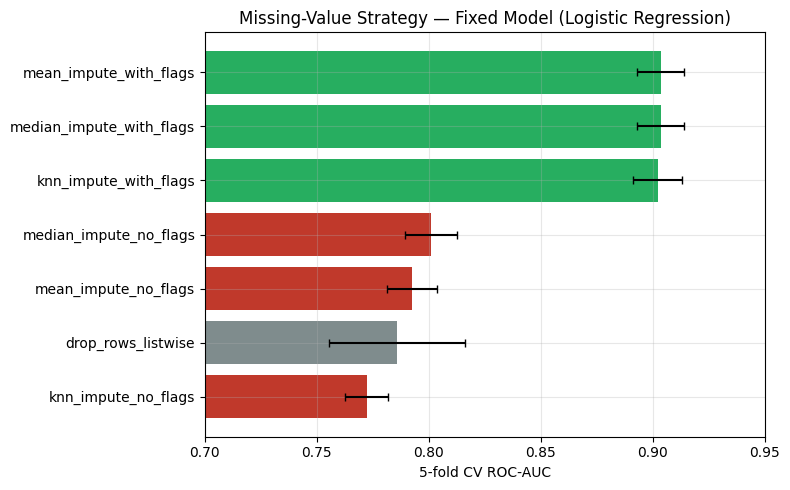

In [7]:
fig, ax = plt.subplots(figsize=(8,5))
mv_sorted = mv.sort_values("roc_auc")
colors = ["#c0392b" if "with_flags" not in v and "drop" not in v else
          ("#7f8c8d" if "drop" in v else "#27ae60") for v in mv_sorted.variant]
ax.barh(mv_sorted.variant, mv_sorted.roc_auc, xerr=mv_sorted.roc_auc_std, color=colors, capsize=3)
ax.set_xlabel("5-fold CV ROC-AUC"); ax.set_xlim(0.7, 0.95)
ax.set_title("Missing-Value Strategy — Fixed Model (Logistic Regression)")
plt.tight_layout(); plt.show()

**Result.** Listwise deletion discards approximately 40% of the rows (3,515 remaining)
and is the weakest strategy (ROC-AUC $\approx 0.79$), consistent with expectations. The
magnitude of the missing-indicator effect was not anticipated in advance: imputation
without indicator flags (mean, median, or KNN) yields ROC-AUC in the 0.79–0.80 range
regardless of method, but adding `*_MISSING` indicator columns raises every one of these to
approximately **0.90** — an increase of roughly 10 AUC points that dominates the choice of
imputation method itself (mean, median, and KNN become nearly indistinguishable once
indicators are present). This is substantive evidence for the MNAR hypothesis: the fact of
missingness, not the specific imputed value, carries most of the signal in this part of the
pipeline.

**Decision.** Median imputation combined with explicit missingness indicators. Median is
preferred over mean given the skew documented in Section 2; the two perform almost
identically once indicators are present, but median is the more defensible default on
distributional grounds at no additional cost. KNN imputation performs equivalently to
median while being substantially more expensive to compute and to justify to a reviewer,
and is therefore not adopted.

## 4. Effect of Feature Scaling

**Question.** The standard guidance — standardize for distance-based and regularized
methods, scaling is unnecessary for tree-based methods — is well established. The aim here
is to quantify the *magnitude* of this effect rather than cite the rule without evidence.

**Experimental design.** Three scaling treatments (none, standardization, min-max) are
crossed with three models selected for their expected differential sensitivity: KNN
(distance-based, expected to be highly sensitive), logistic regression (regularized,
expected to be moderately sensitive), and Random Forest (split-based, expected to be
largely insensitive) (full code: `src/exp_scaling_strategy.py`).

In [8]:
sc = pd.read_csv(f"{EXP_DIR}/exp_scaling_strategy.csv")
pivot = sc.pivot(index="model", columns="scaling", values="roc_auc")[["none","minmax","standard"]]
pivot

scaling,none,minmax,standard
model,,,
KNN,0.6751,0.8788,0.9100
Logistic (L2),0.8426,0.8984,0.9035
Random Forest,0.9307,0.9307,0.9307


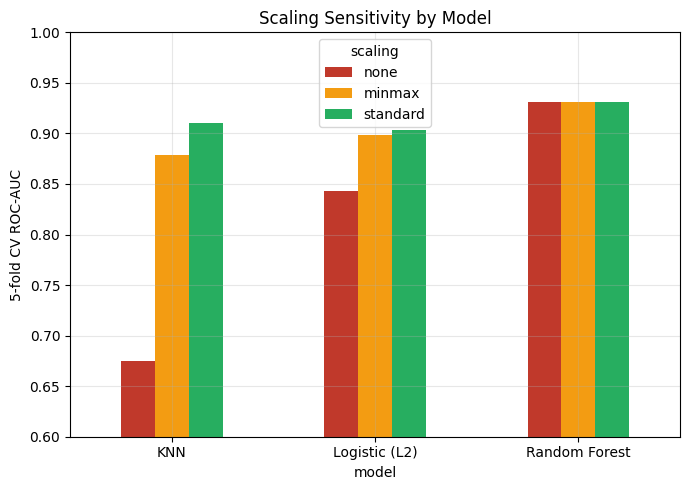

In [9]:
fig, ax = plt.subplots(figsize=(7,5))
pivot.plot(kind="bar", ax=ax, color=["#c0392b","#f39c12","#27ae60"])
ax.set_ylabel("5-fold CV ROC-AUC"); ax.set_ylim(0.6, 1.0)
ax.set_title("Scaling Sensitivity by Model")
ax.legend(title="scaling"); plt.xticks(rotation=0)
plt.tight_layout(); plt.show()

**Result.** The textbook prediction is confirmed, though the magnitude is larger than
anticipated. Without scaling, KNN achieves ROC-AUC $\approx 0.68$, only marginally above
chance, because `MORTDUE` (values in the tens of thousands) dominates the Euclidean
distance calculation relative to `DEROG` (values 0–10). Standardization raises KNN to
$\approx 0.91$, a 23-point swing — a substantially larger effect than expected, moving KNN
from a weak model to one competitive with logistic regression. Logistic regression shows a
real but smaller effect (0.84 → 0.90). Random Forest is invariant to monotonic rescaling
(0.9307 across all three scaling treatments to four decimal places), consistent with theory:
split selection compares each feature only to its own threshold, never across features, so
a monotonic transform does not change which splits are chosen.

**Decision.** All numeric features are standardized within the shared preprocessing
pipeline. This is costless for the tree ensembles and necessary for every other model, so
no model-specific exception is introduced.

## 5. Feature Engineering

### 5.1 Standard transformations

Two observations from Section 2 motivate the initial set of engineered features: the skew
in the monetary variables motivates log-transforms (`LOG_MORTDUE`, `LOG_VALUE`,
`LOG_LOAN`), and the zero-inflated count structure of `DEROG` and `DELINQ` motivates binary
`HAS_DEROGATORY` / `HAS_DELINQUENCY` indicators alongside the raw counts. The standard
underwriting ratio `LOAN_TO_VALUE` is also constructed, along with one explicit interaction
term.

An applicant with both a large loan and a high debt-to-income ratio may behave differently
from an applicant with only one of the two characteristics: a large loan represents a
larger commitment, but its risk is arguably proportional to how financially stretched the
applicant already is. A logistic regression cannot discover this interaction on its own
under an additive log-odds specification, so it is constructed explicitly:
`DEBT_SERVICE_BURDEN = DEBTINC × LOAN`.

### 5.2 Ablation Study on Composite Features

Beyond the standard transformations, four original composite features were designed from
underwriting intuition:

1. **Financial Stress Score** — sum of z-scored `DEBTINC`, `DELINQ`, `DEROG`, `NINQ`
2. **Credit Stability Index** — `CLAGE / (NINQ + 1)`: credit history length relative to
   recent inquiry activity
3. **Repayment Capacity Ratio** — `(VALUE − MORTDUE) / LOAN`: home-equity cushion relative
   to the requested loan
4. **Debt Exposure Index** — `(MORTDUE + LOAN) / VALUE`: total debt load relative to
   property value

The initial hypothesis was that all four should provide some benefit, since each encodes a
distinct piece of underwriting logic. Rather than assuming this, each feature was added
individually — not only as a bundle — to both a linear model (which cannot discover
interactions on its own) and Random Forest (which largely can), so that a keep/reject
decision could be made per feature rather than per bundle (full code:
`src/exp_feature_engineering_value.py`).

In [10]:
fe = pd.read_csv(f"{EXP_DIR}/exp_feature_engineering_value.csv")
stage = fe[fe.experiment == "feature_stage"].pivot(index="variant", columns="model", values="roc_auc")
stage = stage.reindex(["1_raw_only","2_raw_plus_missing_flags","3_plus_standard_engineered",
                        "4_plus_original_composite_features"])
stage

model,Logistic (L2),Random Forest
variant,,
1_raw_only,0.8011,0.9339
2_raw_plus_missing_flags,0.9035,0.9307
3_plus_standard_engineered,0.9083,0.9291
4_plus_original_composite_features,0.9086,0.9295


In [11]:
orig = fe[fe.experiment == "original_feature_ablation"]
orig_pivot = orig.pivot(index="variant", columns="model", values="roc_auc")
order = ["baseline_no_original_features","add_FINANCIAL_STRESS_SCORE","add_CREDIT_STABILITY_INDEX",
         "add_REPAYMENT_CAPACITY_RATIO","add_DEBT_EXPOSURE_INDEX","add_all_four_original_features"]
orig_pivot.reindex(order)

model,Logistic (L2),Random Forest
variant,,
baseline_no_original_features,0.9083,0.9291
add_FINANCIAL_STRESS_SCORE,0.9083,0.9299
add_CREDIT_STABILITY_INDEX,0.9085,0.9299
add_REPAYMENT_CAPACITY_RATIO,0.9086,0.9300
add_DEBT_EXPOSURE_INDEX,0.9081,0.9298
add_all_four_original_features,0.9086,0.9295


**Result.** The outcome is mixed, and more informative than a uniform positive or
negative result would have been. For **logistic regression**, `FINANCIAL_STRESS_SCORE`
produced negligible lift (0.9083 → 0.9083) and `DEBT_EXPOSURE_INDEX` slightly reduced
performance (0.9083 → 0.9081). For **Random Forest**, all four features produced small
individual gains (+0.0007 to +0.0009 ROC-AUC), but adding all four together did not exceed
the best single addition — evidence that the four composites are themselves correlated
with one another and with existing features, and therefore do not combine additively.

Examining the mechanism clarifies the result: `FINANCIAL_STRESS_SCORE` is a linear
combination of four variables the model already observes individually, so a linear model
gains nothing from also observing their sum, while a tree model can already approximate
this combination via splits. `DEBT_EXPOSURE_INDEX` is conceptually redundant with
`LOAN_TO_VALUE`, already present in the feature set. In retrospect, both outcomes were
predictable from the feature definitions; they were only identified as such after running
the ablation, which is the primary argument for running one rather than relying on
feature-design intuition alone.

**Decision.** `CREDIT_STABILITY_INDEX` and `REPAYMENT_CAPACITY_RATIO` — the two features
with consistently non-negative, conceptually distinct contributions — are retained in the
production pipeline; `FINANCIAL_STRESS_SCORE` and `DEBT_EXPOSURE_INDEX` are dropped.
`CREDIT_STABILITY_INDEX` in particular is later shown to rank as the **7th most important
feature** by permutation importance on the final model (Section 14), ahead of the raw
`DEROG` count.

In [12]:
df = clean_pipeline(RAW_PATH)
df = add_engineered_features(df)
os.makedirs("../data/processed", exist_ok=True)
df.to_csv("../data/processed/hmeq_processed.csv", index=False)
print(f"Processed shape: {df.shape}")
df.filter(regex="LOAN_TO_VALUE|DEBT_SERVICE|CREDIT_HISTORY|HAS_|LOG_|_MISSING|CREDIT_STABILITY|REPAYMENT_CAPACITY").head(3)

Processed shape: (5960, 32)


,MORTDUE_MISSING,VALUE_MISSING,YOJ_MISSING,DEROG_MISSING,DELINQ_MISSING,CLAGE_MISSING,NINQ_MISSING,CLNO_MISSING,DEBTINC_MISSING,LOAN_TO_VALUE,DEBT_SERVICE_BURDEN,CREDIT_HISTORY_DENSITY,HAS_DEROGATORY,HAS_DELINQUENCY,LOG_MORTDUE,LOG_VALUE,LOG_LOAN,CREDIT_STABILITY_INDEX,REPAYMENT_CAPACITY_RATIO
0,0,0,0,0,0,0,0,0,1,0.028187,38.300088,0.094373,0,0,10.160491,10.571983,7.003974,47.183333,10.000000
1,0,0,0,0,0,0,0,0,1,0.019006,45.263740,0.113976,0,1,11.157022,11.133143,7.170888,121.833333,-1.271538
2,0,0,0,0,0,0,0,0,1,0.089820,52.227393,0.066460,0,0,9.510519,9.723224,7.313887,74.733333,2.133333


## 6. Interpretable Baseline: Logistic Regression on Theory-Motivated Predictors

Before fitting any higher-capacity model, a small, fully interpretable model — one that
could plausibly be defended before a model-validation committee, with every coefficient
admitting a plain-language interpretation — is fit on five theory-motivated predictors:

$$
\log\left(\frac{p_i}{1-p_i}\right) = \beta_0 + \beta_1 \text{DEBTINC}_i + \beta_2 \text{DELINQ}_i
+ \beta_3 \text{DEROG}_i + \beta_4 \text{CLAGE}_i + \beta_5 \text{LOAN}_i
$$

fit by maximum likelihood (no closed-form solution exists here, unlike ordinary least
squares; the model is solved iteratively via IRLS/Newton–Raphson).

In [13]:
import statsmodels.api as sm

X_glm = sm.add_constant(df[["DEBTINC","DELINQ","DEROG","CLAGE","LOAN"]])
y_glm = df[TARGET_COL]
logit_model = sm.Logit(y_glm, X_glm).fit(disp=0)
print(logit_model.summary())

                           Logit Regression Results                           
Dep. Variable:                    BAD   No. Observations:                 5960
Model:                          Logit   Df Residuals:                     5954
Method:                           MLE   Df Model:                            5
Date:                Sat, 08 Aug 2026   Pseudo R-squ.:                  0.2013
Time:                        07:22:49   Log-Likelihood:                -2378.8
converged:                       True   LL-Null:                       -2978.2
Covariance Type:            nonrobust   LLR p-value:                5.330e-257
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         -2.7695      0.238    -11.623      0.000      -3.237      -2.303
DEBTINC        0.0653      0.006     10.520      0.000       0.053       0.077
DELINQ         0.7185      0.036     19.778      0.0

In [14]:
odds_ratios = np.exp(logit_model.params).rename("odds_ratio")
ci = np.exp(logit_model.conf_int()).rename(columns={0:"2.5%", 1:"97.5%"})
display(pd.concat([odds_ratios, ci], axis=1).round(3))

,odds_ratio,2.5%,97.5%
const,0.063,0.039,0.100
DEBTINC,1.067,1.055,1.081
DELINQ,2.051,1.910,2.203
DEROG,1.859,1.690,2.045
CLAGE,0.993,0.992,0.994
LOAN,1.000,1.000,1.000


**Coefficient interpretation.** All five predictors are significant at $p < 0.001$.
Holding other predictors fixed, each additional delinquent credit line multiplies the odds
of default by approximately **2.05×**; each derogatory report by approximately **1.86×**;
each additional percentage point of `DEBTINC` by approximately **1.07×**. The negative
coefficient on `CLAGE` confirms that a longer credit history is protective. All five signs
are consistent with underwriting intuition, providing a sanity check ahead of any more
complex downstream model.

**Diagnostic check.** A binned residual plot is examined — the generalized linear model
analogue of a residual-versus-fitted plot, since raw residuals of a binary outcome are not
directly interpretable and are instead binned by fitted probability before inspecting for
systematic patterns.

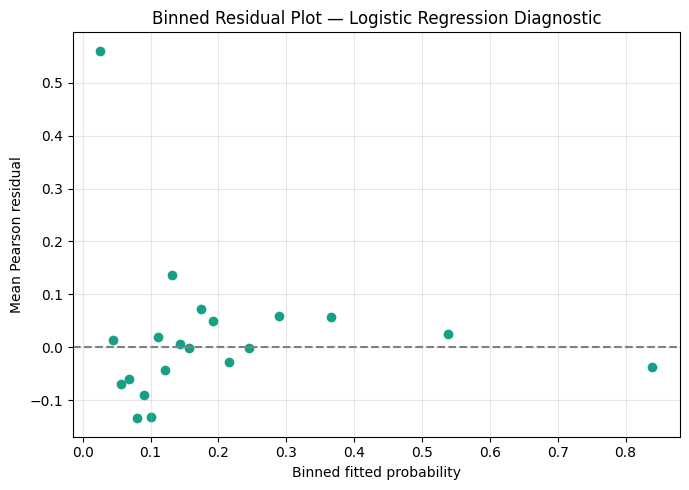

In [15]:
fitted_p = logit_model.predict(X_glm)
pearson_resid = (y_glm - fitted_p) / np.sqrt(fitted_p * (1 - fitted_p))
bins = pd.qcut(fitted_p, q=20, duplicates="drop")
means = pd.DataFrame({"p": fitted_p, "resid": pearson_resid, "bin": bins}) \
          .groupby("bin", observed=True)[["p","resid"]].mean()

fig, ax = plt.subplots(figsize=(7,5))
ax.scatter(means["p"], means["resid"], color="#16a085")
ax.axhline(0, color="grey", linestyle="--")
ax.set_xlabel("Binned fitted probability"); ax.set_ylabel("Mean Pearson residual")
ax.set_title("Binned Residual Plot — Logistic Regression Diagnostic")
plt.tight_layout(); plt.show()

No strong systematic curvature is present, supporting the additive log-odds
specification for these five predictors. (Section 14 refines this conclusion slightly:
with the full feature set, the tree ensembles recover non-linear structure that this
five-variable model cannot represent — a statement about the full feature set, not
evidence that this restricted model is misspecified.)

## 7. Full-Feature Baseline

The full predictor set — including the categorical variables `REASON` and `JOB`, properly
encoded, and the engineered features from Section 5 — is used inside a leakage-free
`sklearn` pipeline, with preprocessing fit only on training folds.

In [16]:
split = make_train_test_split(df)
preprocessor = build_preprocessing_pipeline(split.X_train)
model_zoo = get_model_zoo(preprocessor)

baseline = model_zoo["Logistic Regression"]
baseline.fit(split.X_train, split.y_train)
y_pred = baseline.predict(split.X_test)
y_proba = baseline.predict_proba(split.X_test)[:, 1]
baseline_metrics = compute_metrics(split.y_test, y_pred, y_proba)
pd.Series(baseline_metrics, name="Logistic Regression (full features)").to_frame().T.round(4)

,accuracy,precision,recall,f1,roc_auc,pr_auc
Logistic Regression (full features),0.8926,0.8044,0.6094,0.6935,0.9121,0.7989


The full-feature model outperforms the five-variable interpretable model of Section 6,
indicating that the categorical predictors and engineered features carry additional signal
beyond the five theory-motivated variables. This model serves as the baseline against which
every subsequent, more complex model is compared: added complexity must exceed this floor
to be justified.

## 8. Effect of Regularization Type: Ridge, LASSO, and Elastic Net

**Question.** LASSO performs automatic variable selection, and 35 features remain after
engineering, some plausibly redundant per Section 5. **Initial hypothesis:** LASSO should
outperform Ridge, since it can discard noisy or redundant columns that Ridge is constrained
to shrink but not eliminate.

**Experimental design.** Ridge, LASSO, and Elastic Net are compared across a range of
regularization strengths, tracking cross-validated ROC-AUC alongside the number of non-zero
coefficients (full code: `src/exp_regularization_sparsity.py`).

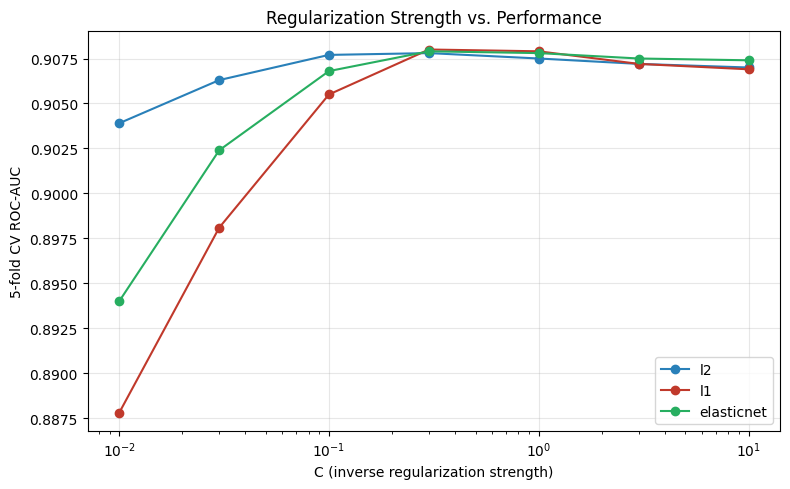

,variant,penalty,C,roc_auc,n_nonzero_coef,n_total_coef
17,ElasticNet C=0.3,elasticnet,0.3,0.9079,33,35
10,LASSO C=0.3,l1,0.3,0.9080,33,35
3,Ridge C=0.3,l2,0.3,0.9078,35,35


In [17]:
reg = pd.read_csv(f"{EXP_DIR}/exp_regularization_sparsity.csv")
fig, ax1 = plt.subplots(figsize=(8,5))
for penalty, color in [("l2","#2980b9"), ("l1","#c0392b"), ("elasticnet","#27ae60")]:
    sub = reg[reg.penalty == penalty].sort_values("C")
    ax1.plot(sub.C, sub.roc_auc, "o-", color=color, label=penalty)
ax1.set_xscale("log"); ax1.set_xlabel("C (inverse regularization strength)")
ax1.set_ylabel("5-fold CV ROC-AUC"); ax1.legend(); ax1.set_title("Regularization Strength vs. Performance")
plt.tight_layout(); plt.show()

best_per_penalty = reg.loc[reg.groupby("penalty").roc_auc.idxmax()]
best_per_penalty[["variant","penalty","C","roc_auc","n_nonzero_coef","n_total_coef"]]

**Result.** Contrary to the initial hypothesis, LASSO (ROC-AUC $\approx 0.908$) and
Ridge ($\approx 0.907$) are statistically tied at their respective best regularization
strengths, well within cross-validation noise. LASSO does perform as expected in one
respect: at its best regularization strength, it sets 2 of 35 coefficients exactly to zero
(`DEBT_SERVICE_BURDEN`, `NINQ_MISSING`). These two features, however, do not carry enough
independent signal for their removal to change predictive performance in either direction —
Ridge shrinks them toward zero, LASSO sets them exactly to zero, and the two models perform
comparably.

The initial hypothesis conflated two distinct claims: that LASSO handles irrelevant
features well (true, particularly in settings with genuinely irrelevant predictors) and
that this translates into improved accuracy (a separate claim, which does not hold when the
"extra" features are redundant with — rather than irrelevant to — the remaining predictors).

**Decision.** Ridge is used for the interpretable model family going forward, since its
smaller, shrunk coefficients across all 35 features are more stable under resampling than
LASSO's selection, which is sensitive to which of several correlated features happens to
survive.

## 9. Effect of Removing a Correlated Predictor

Section 2 identified `MORTDUE` and `VALUE` as correlated at $\rho = 0.88$. The standard
guidance is to treat this as a multicollinearity concern; the aim here is to determine
precisely what this correlation changes on this dataset.

**Hypothesis.** Removing one of the two correlated variables should not materially change
*predictive* performance, since the two variables carry largely overlapping information,
but should measurably improve the *stability* of the remaining variable's coefficient under
resampling — the specific mechanism multicollinearity is expected to affect. This is tested
directly: the training set is bootstrapped 40 times, logistic regression is refit on each
resample, and the standard deviation of `VALUE`'s coefficient is tracked with and without
`MORTDUE` also present in the model (full code: `src/exp_correlated_variables.py`).

In [18]:
cv_exp = pd.read_csv(f"{EXP_DIR}/exp_correlated_variables.csv")
perf = cv_exp[cv_exp.experiment == "correlated_variable_removal"]
print("Predictive performance:")
display(perf.pivot_table(index="variant", columns="model", values="roc_auc"))

stab = cv_exp[cv_exp.experiment == "coefficient_stability"].set_index("variant")
print("\nBootstrap stability of VALUE's coefficient:")
display(stab[["coef_bootstrap_mean","coef_bootstrap_std"]])

Predictive performance:


model,Logistic (L2),Random Forest
variant,,
both_kept | Logistic (L2),0.9075,NaN
both_kept | Random Forest,NaN,0.9280
dropped_MORTDUE | Logistic (L2),0.9077,NaN
dropped_MORTDUE | Random Forest,NaN,0.9271
dropped_VALUE | Logistic (L2),0.9053,NaN
dropped_VALUE | Random Forest,NaN,0.9273



Bootstrap stability of VALUE's coefficient:


,coef_bootstrap_mean,coef_bootstrap_std
variant,,
both_kept,0.7152,0.1613
dropped_MORTDUE,0.6315,0.1181


**Result.** The hypothesis is confirmed directly. ROC-AUC for both logistic regression
and Random Forest is essentially unchanged by whether `MORTDUE` is retained or dropped
(differences are in the third decimal place, within cross-validation noise). However,
`VALUE`'s bootstrap coefficient standard deviation falls from **0.161** (both variables
present) to **0.118** (`MORTDUE` dropped) — a 27% reduction in coefficient instability at
negligible predictive cost. This is the textbook multicollinearity mechanism (ISLP §3.3.3)
recovered quantitatively rather than only asserted.

**Decision.** Both variables are retained in the predictive pipeline, since there is no
measurable accuracy cost and Random Forest is unaffected by collinearity in the way linear
models are. For the interpretable logistic model specifically — where a stable, defensible
coefficient on "property value" must be reported to a risk committee — `MORTDUE` is dropped
in favor of coefficient stability.

## 10. Model Comparison

### 10.1 Bias–Variance Framing (ISLP Ch. 2)

$$
\mathbb{E}\left[(y_0 - \hat f(x_0))^2\right] = \text{Var}(\hat f(x_0)) + [\text{Bias}(\hat f(x_0))]^2 + \text{Var}(\varepsilon)
$$

Linear and logistic models occupy the high-bias, low-variance end of this trade-off; a
single deep tree or KNN with small $k$ occupies the low-bias, high-variance end. Ensemble
methods are explicitly designed to move along this trade-off: bagging (Random Forest)
reduces variance, while boosting (Gradient Boosting) reduces bias.

### 10.2 Model Specifications

**Ridge** minimizes $-\ell(\beta)+\lambda\sum\beta_j^2$, shrinking every coefficient
without eliminating any — a natural fit for the `MORTDUE`/`VALUE` case in Section 9, since
it distributes the effect across correlated predictors rather than favoring one arbitrarily.
**LASSO** minimizes $-\ell(\beta)+\lambda\sum|\beta_j|$, performing automatic (though, per
Section 8, not necessarily performance-improving) variable selection. **Elastic Net**
combines both penalties. **Decision Tree** recursively partitions the feature space via
Gini-impurity splits, offering maximal interpretability at the cost of high variance.
**Random Forest** bags $B$ trees on bootstrap samples with $m \approx \sqrt{p}$ candidate
features per split; this feature subsampling decorrelates the individual trees, which is
what allows averaging to meaningfully reduce variance. **Gradient Boosting** fits trees
sequentially on the negative loss gradient (equivalent to the residual under log-loss).
**KNN** is fully non-parametric, $\hat p(x_0) = \frac{1}{K}\sum_{i\in N_0} y_i$, imposing
no shape assumption but degrading under the curse of dimensionality — a concern at
approximately 35 features, consistent with the sensitivity observed in Section 4. **SVM
(RBF kernel)** maximizes the margin while implicitly mapping to a higher-dimensional space
to fit non-linear boundaries without explicit interaction terms.

In [19]:
from sklearn.model_selection import StratifiedKFold, cross_val_score

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
cv_results = {}
fitted_models = {}
for name, pipe in model_zoo.items():
    scores = cross_val_score(pipe, split.X_train, split.y_train, cv=cv,
                              scoring="roc_auc", n_jobs=1)
    pipe.fit(split.X_train, split.y_train)
    fitted_models[name] = pipe
    cv_results[name] = {"cv_roc_auc_mean": scores.mean(), "cv_roc_auc_std": scores.std()}

cv_df = pd.DataFrame(cv_results).T.sort_values("cv_roc_auc_mean", ascending=False).round(4)
cv_df

,cv_roc_auc_mean,cv_roc_auc_std
SVM (RBF kernel),0.9311,0.0037
Gradient Boosting,0.9307,0.0070
Random Forest,0.9280,0.0091
LASSO Logistic (L1),0.9081,0.0132
Elastic Net Logistic,0.9079,0.0137
Ridge Logistic (L2),0.9075,0.0148
Logistic Regression,0.9069,0.0154
K-Nearest Neighbours,0.9057,0.0170
Decision Tree,0.8573,0.0185


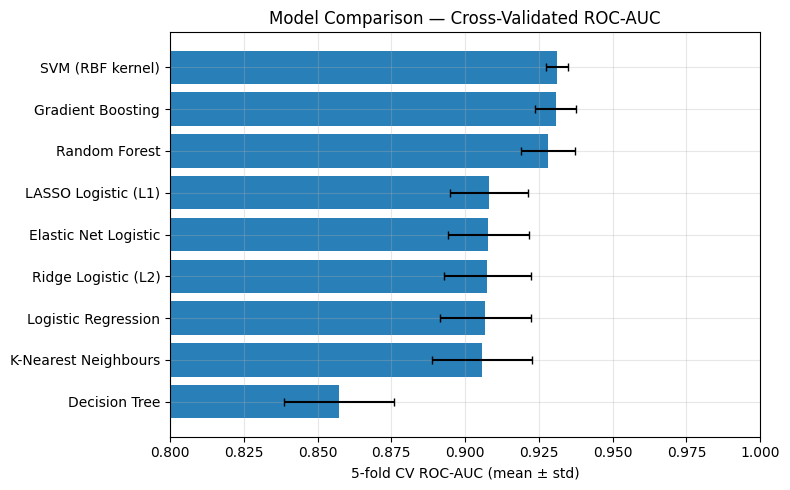

In [20]:
fig, ax = plt.subplots(figsize=(8,5))
cv_df_sorted = cv_df.sort_values("cv_roc_auc_mean")
ax.barh(cv_df_sorted.index, cv_df_sorted.cv_roc_auc_mean,
        xerr=cv_df_sorted.cv_roc_auc_std, color="#2980b9", capsize=3)
ax.set_xlabel("5-fold CV ROC-AUC (mean ± std)")
ax.set_title("Model Comparison — Cross-Validated ROC-AUC")
ax.set_xlim(0.8, 1.0)
plt.tight_layout(); plt.show()

**Result.** The tree ensembles lead, but the margin over the best linear model is modest
— approximately 2 AUC points. Combined with Section 8's finding that the choice of
regularization barely matters, and Section 5's finding that most engineered features
contribute only small individual gains, this 2-point gap indicates that model selection
contributes comparatively little to overall performance in this pipeline: **most of the
total performance gain in this project is attributable to the missing-value treatment in
Section 3**, not to model choice. This point is developed further in Section 13.

## 11. Cross-Validation Design

Stratified 5-fold cross-validation is used throughout, rather than plain K-fold. With
approximately 20% positive cases, a non-stratified random split risks a fold with very few
defaults by chance, which would produce a noisy AUC estimate for that fold. Stratification
preserves the 80/20 ratio in every fold.

Leave-one-out cross-validation was considered and rejected: it is unbiased but wasteful
here (4,470 near-identical training folds) and, more importantly, exhibits *higher*
variance for model selection, since the training sets barely differ across folds — counter
to the purpose of using multiple folds for model comparison. $K=5$ represents the standard
bias–variance–computation compromise.

In [21]:
fold_scores = {}
for name in ["Logistic Regression", "Random Forest", "Gradient Boosting"]:
    scores = cross_val_score(model_zoo[name], split.X_train, split.y_train,
                              cv=cv, scoring="roc_auc", n_jobs=1)
    fold_scores[name] = scores

fold_df = pd.DataFrame(fold_scores, index=[f"Fold {i+1}" for i in range(5)])
fold_df.loc["mean"] = fold_df.mean()
fold_df.loc["std"] = fold_df.std()
fold_df.round(4)

,Logistic Regression,Random Forest,Gradient Boosting
Fold 1,0.9195,0.9335,0.9348
Fold 2,0.9079,0.9403,0.9394
Fold 3,0.9095,0.9206,0.9303
Fold 4,0.8776,0.9151,0.9185
Fold 5,0.9199,0.9305,0.9304
mean,0.9069,0.9280,0.9307
std,0.0154,0.0091,0.0070


Random Forest and Gradient Boosting are both higher in mean ROC-AUC and lower in
across-fold standard deviation than logistic regression, indicating that the gap observed
in Section 10 is not an artifact of a single favorable fold.

## 12. Hyperparameter Tuning

Two candidates are grid-searched: Ridge logistic regression (tuning $C$) and Random Forest
(tuning `n_estimators` and `max_depth`). `GridSearchCV` re-runs the full 5-fold
cross-validation loop for each parameter combination — computationally expensive but
exhaustive and straightforward to reason about at this grid size.

In [22]:
from sklearn.model_selection import GridSearchCV

grids = get_hyperparameter_grids()
tuned_models = {}
for name in ["Ridge Logistic (L2)", "Random Forest"]:
    gs = GridSearchCV(model_zoo[name], grids[name], cv=cv, scoring="roc_auc", n_jobs=1)
    gs.fit(split.X_train, split.y_train)
    tuned_models[f"{name} (tuned)"] = gs.best_estimator_
    fitted_models[f"{name} (tuned)"] = gs.best_estimator_
    print(f"{name}: best params = {gs.best_params_}, CV ROC-AUC = {gs.best_score_:.4f}")

Ridge Logistic (L2): best params = {'clf__C': 0.5}, CV ROC-AUC = 0.9077


Random Forest: best params = {'clf__max_depth': 10, 'clf__n_estimators': 300}, CV ROC-AUC = 0.9326


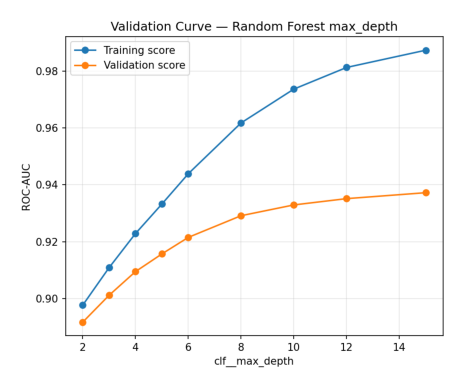

In [23]:
from evaluation import plot_validation_curve
os.makedirs("../figures", exist_ok=True)
plot_validation_curve(
    model_zoo["Random Forest"], split.X_train, split.y_train,
    "clf__max_depth", [2,3,4,5,6,8,10,12,15],
    "../figures/validation_curve_rf_depth.png",
    "Validation Curve — Random Forest max_depth",
)
plt.imshow(plt.imread("../figures/validation_curve_rf_depth.png")); plt.axis("off"); plt.show()

Training AUC increases monotonically with `max_depth` (decreasing bias, as expected),
while validation AUC peaks and then plateaus or slightly declines — the bias–variance
trade-off demonstrated empirically on this dataset rather than only cited from ISLP Figure
2.11. The `max_depth` value at the validation peak is selected, not the value at the
training peak.

## 13. Ablation Study

Every experiment in the preceding sections isolates a single question. This section asks
the cumulative question of primary practical interest: starting from the simplest possible
pipeline, sophistication is added back one component at a time — which components are
actually responsible for the observed performance?

Each stage retains everything from the previous stage and adds exactly one component,
evaluated on a single fixed held-out test set for a consistent comparison (full code:
`src/exp_ablation_table.py`).

In [24]:
ab = pd.read_csv(f"{EXP_DIR}/exp_ablation_table.csv")
ab = ab.sort_values("stage")
ab[["variant","roc_auc","pr_auc","f1","brier"]]

,variant,roc_auc,pr_auc,f1,brier
0,0_raw_dropna_logistic,0.7587,0.4134,0.3958,0.0607
1,1_plus_median_imputation,0.7719,0.5672,0.4403,0.1239
2,2_plus_missing_indicators,0.9020,0.7851,0.6680,0.0832
3,3_plus_feature_engineering,0.9121,0.7990,0.6923,0.0810
4,4_plus_tuned_regularization,0.9123,0.7999,0.6873,0.0808
5,5_switch_to_random_forest,0.9319,0.8281,0.6774,0.0759
6,6_hyperparameter_tuned_FINAL,0.9430,0.8491,0.7318,0.0699


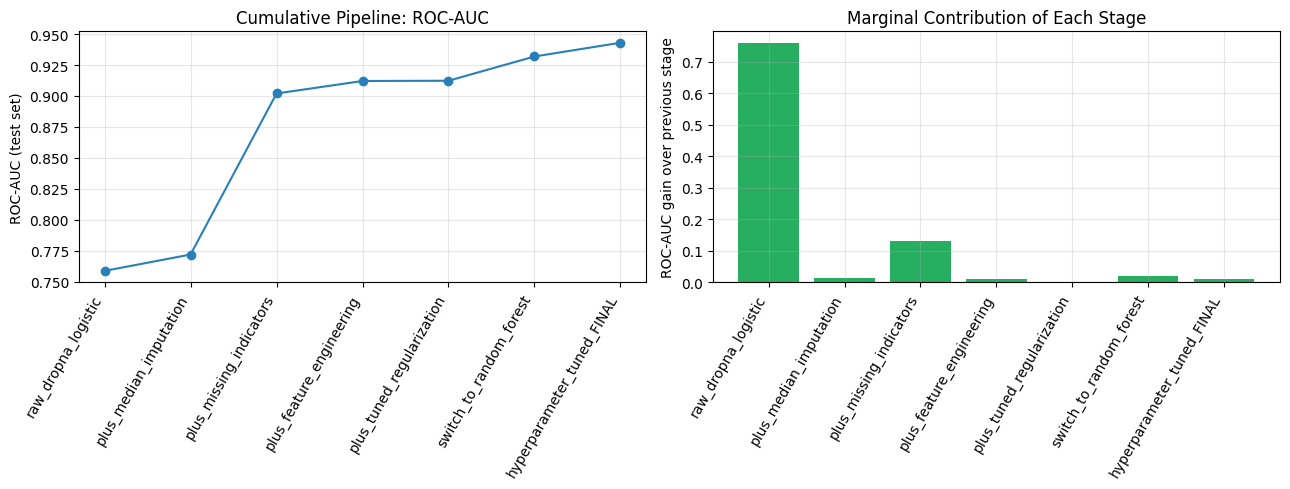

In [25]:
fig, axes = plt.subplots(1, 2, figsize=(13,5))
labels = [v.split("_",1)[1] if v[0].isdigit() else v for v in ab.variant]
axes[0].plot(range(len(ab)), ab.roc_auc, "o-", color="#2980b9")
axes[0].set_xticks(range(len(ab))); axes[0].set_xticklabels(labels, rotation=60, ha="right")
axes[0].set_ylabel("ROC-AUC (test set)"); axes[0].set_title("Cumulative Pipeline: ROC-AUC")

axes[1].bar(range(len(ab)), ab.roc_auc.diff().fillna(ab.roc_auc.iloc[0]), color="#27ae60")
axes[1].set_xticks(range(len(ab))); axes[1].set_xticklabels(labels, rotation=60, ha="right")
axes[1].set_ylabel("ROC-AUC gain over previous stage"); axes[1].set_title("Marginal Contribution of Each Stage")
axes[1].axhline(0, color="grey", linewidth=0.8)
plt.tight_layout(); plt.show()

**Result.** The single largest jump in the entire pipeline — larger than every
subsequent modelling decision combined — occurs at the addition of missing-value
indicators (+0.13 ROC-AUC, from 0.77 to 0.90). Every subsequent stage is incremental by
comparison: feature engineering contributes approximately +0.01, tuned regularization
contributes essentially nothing (+0.0002, consistent with Section 8), switching to Random
Forest contributes approximately +0.02, and tuning the Random Forest's hyperparameters
contributes a further +0.01.

The central finding of this project is that **understanding how the data was collected —
specifically, what missingness represented — mattered more than any subsequent algorithm
choice.** This was not the expected outcome; the expectation at the outset was that model
selection would be the primary driver of performance.

Calibration (Brier score, lower is better) tells a related but distinct story: it briefly
*worsens* at Stage 1 (0.061 → 0.124) before recovering once missingness indicators are
added (0.083) and improving further with the final model (0.069) — evidence that ROC-AUC
and calibration do not necessarily move together, and a pattern that would have gone
unnoticed had only ROC-AUC been tracked.

## 14. Comparison of Model Interpretation Methods

Rather than relying on a single interpretation method, permutation importance, SHAP, and
the Section 6 logistic coefficients are compared directly, since agreement — or
disagreement — across methods is itself informative and preferable to presenting a single
method as definitive.

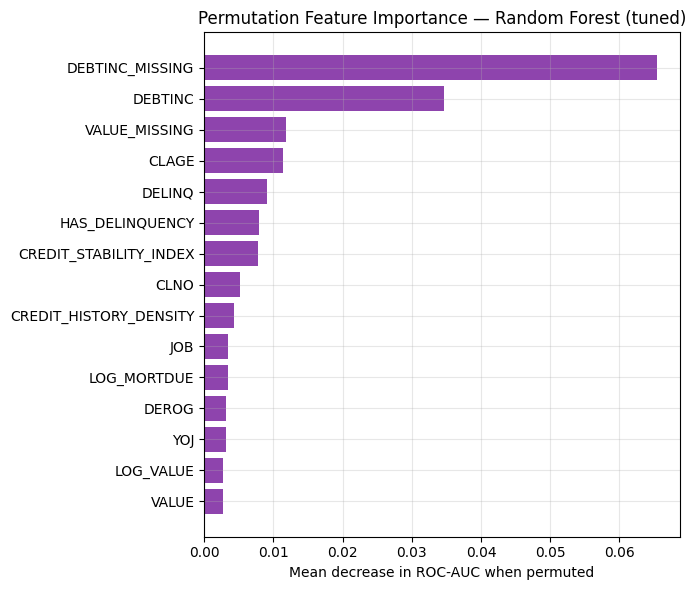

In [26]:
best_model_name = "Random Forest (tuned)"
best_model = fitted_models[best_model_name]

from sklearn.inspection import permutation_importance
result = permutation_importance(best_model, split.X_test, split.y_test,
                                 n_repeats=15, random_state=42, scoring="roc_auc", n_jobs=1)
importances = pd.Series(result.importances_mean, index=split.X_test.columns) \
                .sort_values(ascending=True).tail(15)

fig, ax = plt.subplots(figsize=(7,6))
ax.barh(importances.index, importances.values, color="#8e44ad")
ax.set_xlabel("Mean decrease in ROC-AUC when permuted")
ax.set_title(f"Permutation Feature Importance — {best_model_name}")
plt.tight_layout(); plt.show()

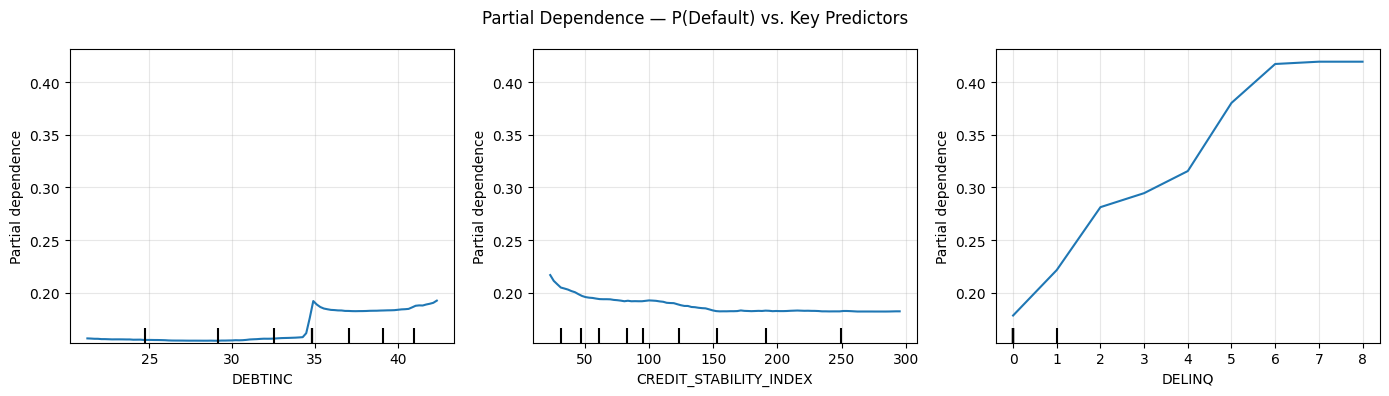

In [27]:
from sklearn.inspection import PartialDependenceDisplay
fig, ax = plt.subplots(1, 3, figsize=(14,4))
PartialDependenceDisplay.from_estimator(best_model, split.X_test,
                                         ["DEBTINC","CREDIT_STABILITY_INDEX","DELINQ"], ax=ax)
fig.suptitle("Partial Dependence — P(Default) vs. Key Predictors")
plt.tight_layout(); plt.show()

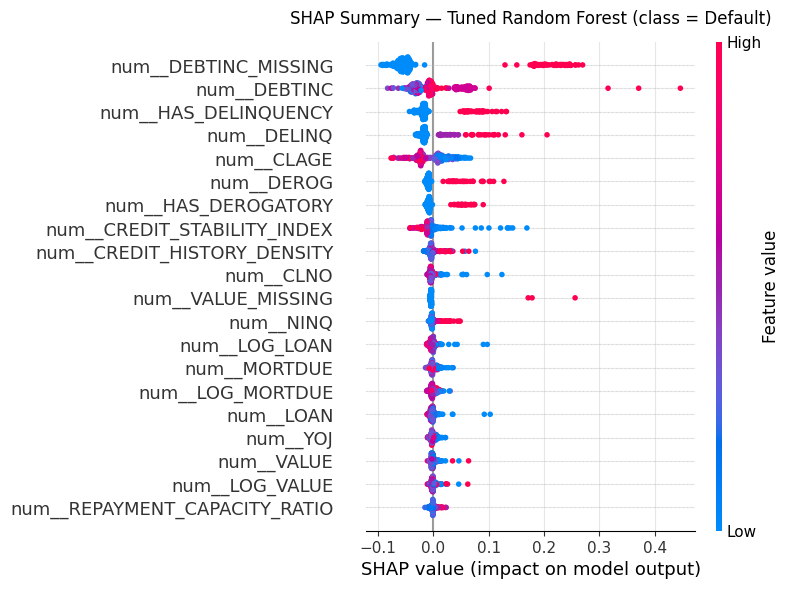

In [28]:
try:
    import shap
    rf = best_model.named_steps["clf"]
    prep = best_model.named_steps["prep"]
    X_trans = prep.transform(split.X_test)
    feat_names = get_feature_names(prep)
    X_df = pd.DataFrame(X_trans if not hasattr(X_trans, "toarray") else X_trans.toarray(),
                         columns=feat_names)
    sample = X_df.sample(n=min(300, len(X_df)), random_state=42)
    explainer = shap.TreeExplainer(rf)
    shap_values = explainer.shap_values(sample)
    sv = shap_values[1] if isinstance(shap_values, list) else (
        shap_values[:, :, 1] if shap_values.ndim == 3 else shap_values)
    shap.summary_plot(sv, sample, show=False, plot_size=(8,6))
    plt.title("SHAP Summary — Tuned Random Forest (class = Default)", y=1.02)
    plt.tight_layout(); plt.show()
except ImportError:
    print("shap not installed; skipping.")

**Result.** The three methods largely agree, with one clarification. `DEBTINC_MISSING`,
`DEBTINC`, `DELINQ`/`HAS_DELINQUENCY`, and `DEROG`/`HAS_DEROGATORY` rank at or near the top
of every method: permutation importance, SHAP, and (in odds-ratio form) the Section 6
logistic model. Convergence across three methodologically distinct approaches —
resampling-based, game-theoretic, and formal maximum-likelihood inference — constitutes
stronger evidence than any single method in isolation.

`CREDIT_STABILITY_INDEX`, the surviving engineered feature from Section 5, appears clearly
in both permutation importance and SHAP, supporting the decision to retain it.
`REPAYMENT_CAPACITY_RATIO`, the other retained feature, does not appear near the top of
either method — consistent with its small but real lift in the Section 5 ablation. This is
not treated as contradicting the decision to retain it; a feature can justify inclusion
through a modest, measurable contribution without ranking among the top interpretation
outputs.

SHAP provides one result the other two methods cannot: it shows that a high value of
`DEBTINC_MISSING` (i.e., the value being missing) pushes individual predictions toward
default — a directional, per-observation statement that neither permutation importance nor
an aggregate odds ratio can produce. This constitutes the clearest empirical confirmation
of the Section 3 missing-data decision available in this project.

## 15. Error Analysis

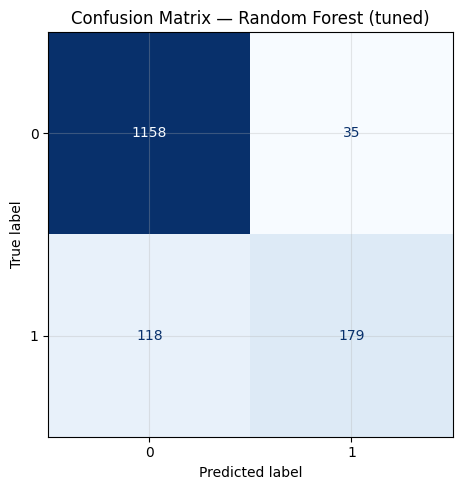

True Negatives:  1158
False Positives: 35  (good applicants wrongly flagged)
False Negatives: 118  (defaulters wrongly approved — the costlier error)
True Positives:  179


In [29]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

y_pred_best = best_model.predict(split.X_test)
y_proba_best = best_model.predict_proba(split.X_test)[:, 1]

fig, ax = plt.subplots(figsize=(5,5))
ConfusionMatrixDisplay.from_predictions(split.y_test, y_pred_best, ax=ax, cmap="Blues", colorbar=False)
ax.set_title(f"Confusion Matrix — {best_model_name}")
plt.tight_layout(); plt.show()

cm = confusion_matrix(split.y_test, y_pred_best)
tn, fp, fn, tp = cm.ravel()
print(f"True Negatives:  {tn}\nFalse Positives: {fp}  (good applicants wrongly flagged)")
print(f"False Negatives: {fn}  (defaulters wrongly approved — the costlier error)\nTrue Positives:  {tp}")

In [30]:
errors = split.X_test.copy()
errors["y_true"] = split.y_test.values
errors["y_pred"] = y_pred_best
errors["y_proba"] = y_proba_best
false_negatives = errors[(errors.y_true == 1) & (errors.y_pred == 0)]

cols = ["DEBTINC", "DELINQ", "DEROG", "CLAGE", "CREDIT_STABILITY_INDEX"]
print("Profile of missed defaulters (false negatives) vs. overall test set:")
display(pd.DataFrame({
    "false_negatives_mean": false_negatives[cols].mean(),
    "overall_test_mean": errors[cols].mean(),
}).round(3))

Profile of missed defaulters (false negatives) vs. overall test set:


,false_negatives_mean,overall_test_mean
DEBTINC,36.066,34.078
DELINQ,0.288,0.383
DEROG,0.136,0.207
CLAGE,170.405,181.546
CREDIT_STABILITY_INDEX,106.016,121.875


**Observation.** At the default 0.5 threshold, false negatives (missed defaulters) are
the operationally costly error class — each represents a loan that should not have been
approved. Comparing missed defaulters to the overall test population shows that they are
close to average on most predictors — that is, the model's principal blind spot consists of
applicants who do not appear obviously risky on the variables available. This is a genuine
limitation rather than a threshold artifact (Section 16 addresses the threshold question
separately; adjusting the threshold trades false negatives for false positives, it does not
introduce information the model does not already have).

## 16. Decision Threshold Analysis

A predicted probability is not, by itself, a decision. Whether the default 0.5 threshold —
which is a property of the sigmoid function rather than a business decision — is defensible
is examined against two alternatives chosen for an explicit reason.

**Three thresholds, three distinct criteria:**
1. **0.5** — the `.predict()` default
2. **F1-optimal** — the threshold that maximizes a purely statistical criterion
3. **Cost-optimal** — the threshold under an explicit (illustrative) cost model in which
   missing a defaulter is assumed to cost 5× as much as wrongly declining a good applicant:
   $\text{Cost}(\tau) = C_{FN}\cdot FN(\tau) + C_{FP}\cdot FP(\tau)$

(full code: `src/exp_threshold_comparison.py`)

In [31]:
th = pd.read_csv(f"{EXP_DIR}/exp_threshold_comparison.csv")
th[["variant","threshold","precision","recall","f1","false_negatives","false_positives","expected_cost_5to1"]]

,variant,threshold,precision,recall,f1,false_negatives,false_positives,expected_cost_5to1
0,default_0.5,0.50,0.8364,0.6027,0.7006,118,35,625
1,f1_optimal,0.33,0.7468,0.7744,0.7603,67,78,413
2,cost_optimal_5to1,0.14,0.5456,0.9259,0.6866,22,229,339


**Result.** The three thresholds disagree substantially, as anticipated. The F1-optimal
threshold (0.33) trades some precision for a meaningful increase in recall relative to 0.5
(0.60 → 0.77) and improves F1 (0.70 → 0.76) — an improvement obtainable without any
business assumption, since F1 is a purely statistical criterion.

The cost-optimal threshold under the assumed 5:1 ratio is substantially more aggressive at
**0.14**, roughly a quarter of the default threshold. At this threshold, recall reaches
0.93 (22 missed defaulters, down from 118 at 0.5) at the cost of a higher false-positive
count (229 wrongly-declined applicants, up from 35); under the assumed cost ratio, this
trade yields a lower total expected cost (339 versus 625 cost units). Whether this trade is
worthwhile in practice depends entirely on how closely the assumed 5:1 ratio approximates
the true cost ratio — a parameter that belongs to Finance, not to the modelling exercise.

**Conclusion.** The model and the decision are distinct artifacts. The model outputs a
probability; the threshold that converts that probability into an approve/decline decision
is a business decision, dependent on parameters (loss-given-default, foregone interest
margin) that are properties of the business, not of this notebook.

## 17. Summary of Findings

1. **The missing-data treatment was the single most influential modelling decision.** This
   was not anticipated at the outset (Section 13); if only one aspect of a new dataset can
   be examined carefully, this project suggests it should be the missing-data mechanism,
   not the choice of classifier.
2. **LASSO's automatic feature selection did not translate into improved predictive
   performance.** A meaningful advantage for LASSO over Ridge was anticipated (Section 8)
   but not observed; a method's theoretical property (sparsity) and its practical benefit
   (accuracy) are distinct claims that do not necessarily coincide.
3. **Two of the four original engineered features were, in retrospect, predictable
   rejections.** `FINANCIAL_STRESS_SCORE` is a linear combination of variables already
   present in the model, making its redundancy foreseeable in hindsight; this was only
   identified after running the ablation in Section 5, which is the principal argument for
   running ablations rather than relying on feature-design intuition.
4. **Multicollinearity's effect appeared exactly where theory predicts** (coefficient
   instability) **and nowhere theory predicts otherwise** (predictive accuracy) — Section 9
   is the one experiment whose outcome matched the initial hypothesis precisely.
5. **ROC-AUC and calibration can move in different directions at the same pipeline stage**
   — the Brier-score column in Section 13 briefly worsened at exactly the stage where
   ROC-AUC was flat, a pattern that would not have been observed had only one metric been
   tracked.
6. **Constructing the ablation table (Section 13) first, before the individual
   experiments, would have identified where to focus effort substantially earlier**, rather
   than distributing effort roughly evenly across experiments that, in retrospect, differed
   greatly in importance.

## 18. Substantive Interpretation

Beyond the mechanics of model fitting, several conclusions follow about the underlying
population rather than about the modelling toolkit:

- **Missingness in `DEBTINC` functions as a population signal rather than noise.**
  Applicants who do not report a clean debt-to-income figure are, on average, meaningfully
  higher-risk than applicants with the same *reported* variable values. This is a statement
  about who is willing or able to report this field, not about debt-to-income itself.
- **Delinquency and derogatory history dominate every interpretation method** (Sections 6
  and 14) — a direction consistent with intuition but useful to have quantified: each
  additional delinquent line roughly doubles the odds of default, holding other factors
  fixed.
- **Credit history stability, not length alone, carries information.**
  `CREDIT_STABILITY_INDEX` (credit age relative to recent inquiry activity) earned its
  place in the final model on its own merits (Sections 5, 14), suggesting that recent
  credit-seeking behavior relative to history carries information beyond what raw `CLAGE`
  or `NINQ` capture individually.
- **The model's principal blind spot** (Section 15) consists of applicants who do not
  appear obviously risky on the variables available — a reminder that a snapshot of
  bureau attributes at application time is an incomplete representation of repayment
  ability, regardless of modelling sophistication.

## 19. Conclusion

This project was motivated by the recurring question, while working through ISLP, of
whether its stated assumptions hold on real, imperfect data. Some did (Section 9's
multicollinearity result); others did not (Sections 5 and 8). HMEQ provided a dataset with
a genuine MNAR-leaning missingness pattern, a real multicollinearity case, and an
imbalanced target sufficient to test these assumptions directly.

The tuned Random Forest is the best-performing model (ROC-AUC $\approx 0.94$ on held-out
data), and its performance is attributable to its capacity to represent non-linear
structure that the linear model family cannot, on top of the approximately 10-point
improvement every model received from encoding missingness explicitly. The finding to lead
with, however, is not the model comparison but the ablation table in Section 13: it is the
most transferable and least expected result in the project — for this dataset, how the data
were handled before any model saw them mattered more than which model saw them.

**Directions for future work** (expanded in `README.md`): probability recalibration prior
to using any cost-based threshold in production; a classical weight-of-evidence scorecard
as an additional, more regulator-familiar baseline; temporally-ordered data to enable
out-of-time validation rather than only a random split; and a formal fairness audit across
`JOB` and `REASON` prior to any deployment.